# 01 · LLM Basics — Next-Token Prediction, Decoding & Alignment

**Lecture slides 4–20.** A language model is a probability distribution over token sequences. Autoregressive (AR) models factor it as

$$p(x_1, \dots, x_L) = \prod_{t=1}^{L} p(x_t \mid x_1, \dots, x_{t-1})$$

so all we need is a model that **predicts the next token given the past context**. In this notebook we open up a tiny real LLM and walk through the full generation pipeline from the slides:

1. **Tokenize** → 2. **Forward** → 3. **Predict next-token probabilities** → 4. **Sample** → 5. **Detokenize**

then look at the training loss, decoding strategies (greedy, top-k, top-p, temperature), and why a pre-trained model still needs **post-training** to become an assistant.

We use [`SmolLM2-135M`](https://huggingface.co/HuggingFaceTB/SmolLM2-135M) (a *base* model, pre-training only) and its instruction-tuned twin `SmolLM2-135M-Instruct`. Both are small enough (~270 MB each) to run on a laptop CPU and download automatically on first use.

In [1]:
# %pip install -q torch transformers matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer

BASE_MODEL_ID = "HuggingFaceTB/SmolLM2-135M"               # pre-trained only
INSTRUCT_MODEL_ID = "HuggingFaceTB/SmolLM2-135M-Instruct"  # pre-trained + post-trained (SFT + preference tuning)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(BASE_MODEL_ID, dtype=torch.float32)
model.eval()
print(f"{sum(p.numel() for p in model.parameters()) / 1e6:.0f}M parameters")

/Users/rinabuoy/miniforge3/envs/LLMs/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/272 [00:00<00:42,  6.41it/s]

Loading weights:  94%|█████████▍| 257/272 [00:00<00:00, 1222.37it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 1022.89it/s]

135M parameters


## Step 1 · Tokenize

The model never sees characters or words — it sees integer **token ids** from a fixed vocabulary. Notice that a token is often a word piece, and that the leading space is part of the token (shown as `Ġ` in the raw vocabulary).

In [2]:
text = "The teddy bear sat on the"
input_ids = tokenizer(text, return_tensors="pt").input_ids

print("Vocabulary size:", tokenizer.vocab_size)
print("Token ids:", input_ids[0].tolist())
for token_id in input_ids[0]:
    print(f"  {token_id.item():>6}  {tokenizer.convert_ids_to_tokens(token_id.item())!r:12} -> {tokenizer.decode(token_id)!r}")

Vocabulary size: 49152
Token ids: [504, 44411, 7012, 2643, 335, 260]
     504  'The'        -> 'The'
   44411  'Ġteddy'     -> ' teddy'
    7012  'Ġbear'      -> ' bear'
    2643  'Ġsat'       -> ' sat'
     335  'Ġon'        -> ' on'
     260  'Ġthe'       -> ' the'


### Context window

The **context window** is the maximum number of tokens the model can process in one go. For a chatbot it has to hold *everything*: system instructions, the conversation history, attached files, retrieved documents… and the tokens it generates.

In [3]:
print("Context window of this model:", model.config.max_position_embeddings, "tokens")

Context window of this model: 8192 tokens


## Where the training samples come from

Every position in a sentence is a training sample: the context so far is the input, and the next token is the label. One sentence of *N* tokens yields *N − 1* next-token classification problems — this is why pre-training scales so easily on raw text (no human labels needed).

In [4]:
sentence = "Teddy bears are soft toys that children love."
sentence_ids = tokenizer(sentence).input_ids

for t in range(1, len(sentence_ids)):
    context = tokenizer.decode(sentence_ids[:t])
    target = tokenizer.decode(sentence_ids[t])
    print(f"{context!r:50} -> {target!r}")

'T'                                                -> 'ed'
'Ted'                                              -> 'dy'
'Teddy'                                            -> ' bears'
'Teddy bears'                                      -> ' are'
'Teddy bears are'                                  -> ' soft'
'Teddy bears are soft'                             -> ' toys'
'Teddy bears are soft toys'                        -> ' that'
'Teddy bears are soft toys that'                   -> ' children'
'Teddy bears are soft toys that children'          -> ' love'
'Teddy bears are soft toys that children love'     -> '.'


## Steps 2 & 3 · Forward pass and next-token probabilities

The forward pass returns one vector of **logits** (one score per vocabulary entry) for every input position. The last position's logits, passed through a softmax, give $p(x_{t+1} \mid x_{\le t})$.

In [5]:
with torch.no_grad():
    logits = model(input_ids).logits

print("logits shape (batch, seq_len, vocab):", tuple(logits.shape))

next_token_probs = F.softmax(logits[0, -1], dim=-1)
top = torch.topk(next_token_probs, 10)
print(f"\nTop-10 next tokens after {text!r}:")
for prob, token_id in zip(top.values, top.indices):
    print(f"  {prob.item():6.2%}  {tokenizer.decode(token_id)!r}")

logits shape (batch, seq_len, vocab): (1, 6, 49152)

Top-10 next tokens after 'The teddy bear sat on the':
  10.09%  ' bed'
   9.03%  ' table'
   4.42%  ' couch'
   4.00%  ' floor'
   3.55%  ' so'
   3.26%  ' edge'
   2.09%  ' ground'
   1.92%  ' chair'
   1.34%  ' bench'
   1.32%  ' arm'


## The loss function: cross-entropy on the next token

Training is a classification problem: *classify the index of the next token*. The loss is the cross-entropy between the predicted distribution and the true next token, averaged over positions — minimizing it is the same as **maximizing the log-likelihood of the text**.

Below we compute it by hand and check it against the loss Hugging Face computes when we pass `labels=`. **Perplexity** = `exp(loss)` is the same number on a more intuitive scale ("how many tokens the model is choosing between, on average").

In [6]:
def sentence_loss(text: str, verbose: bool = False) -> float:
    enc = tokenizer(text, return_tensors="pt")
    with torch.no_grad():
        out = model(**enc, labels=enc.input_ids)  # HF shifts labels by one internally

    # The same thing by hand: position t predicts token t+1
    log_probs = F.log_softmax(out.logits[0, :-1], dim=-1)
    targets = enc.input_ids[0, 1:]
    token_log_probs = log_probs[torch.arange(len(targets)), targets]
    manual_loss = -token_log_probs.mean()

    if verbose:
        for token_id, lp in zip(targets, token_log_probs):
            print(f"  p({tokenizer.decode(token_id)!r:12} | context) = {lp.exp().item():6.2%}   -log p = {-lp.item():5.2f}")
        print(f"  manual loss = {manual_loss.item():.4f}   HF loss = {out.loss.item():.4f}")
    return out.loss.item()


sentence_loss(sentence, verbose=True)

print()
for s in [sentence, "love children that toys soft are bears Teddy."]:
    loss = sentence_loss(s)
    print(f"loss={loss:5.2f}  perplexity={torch.tensor(loss).exp().item():8.1f}  {s!r}")

  p('ed'         | context) =  0.02%   -log p =  8.63
  p('dy'         | context) = 35.85%   -log p =  1.03
  p(' bears'     | context) =  0.31%   -log p =  5.78
  p(' are'       | context) =  7.52%   -log p =  2.59
  p(' soft'      | context) =  0.09%   -log p =  7.06
  p(' toys'      | context) =  0.33%   -log p =  5.72
  p(' that'      | context) = 27.83%   -log p =  1.28
  p(' children'  | context) =  1.82%   -log p =  4.01
  p(' love'      | context) = 35.37%   -log p =  1.04
  p('.'          | context) =  8.87%   -log p =  2.42
  manual loss = 3.9549   HF loss = 3.9549



loss= 3.95  perplexity=    52.2  'Teddy bears are soft toys that children love.'


loss= 7.75  perplexity=  2327.7  'love children that toys soft are bears Teddy.'


The fluent sentence gets a much lower loss than the same words scrambled — the model has learned what language *looks like*.

## Steps 4 & 5 · Autoregressive generation

Generation is just the forward pass in a loop: predict the next token, append it to the context, repeat. Here we use **greedy decoding** — always take the most probable token.

In [7]:
def generate_greedy(prompt: str, max_new_tokens: int = 12, verbose: bool = True) -> str:
    ids = tokenizer(prompt, return_tensors="pt").input_ids
    for step in range(max_new_tokens):
        with torch.no_grad():
            next_logits = model(ids).logits[0, -1]
        next_id = next_logits.argmax()                          # greedy: p = max P(w | C)
        ids = torch.cat([ids, next_id.view(1, 1)], dim=1)       # append to the context
        if verbose:
            print(f"step {step + 1:2}: + {tokenizer.decode(next_id)!r}")
        if next_id.item() == tokenizer.eos_token_id:
            break
    return tokenizer.decode(ids[0])                             # detokenize


print(generate_greedy("The teddy bear sat on the"))

step  1: + ' bed'


step  2: + ','
step  3: + ' and'


step  4: + ' the'


step  5: + ' teddy'


step  6: + ' bear'


step  7: + ' sat'


step  8: + ' on'


step  9: + ' the'
step 10: + ' bed'


step 11: + '.'


step 12: + '\n'
The teddy bear sat on the bed, and the teddy bear sat on the bed.



Greedy decoding is deterministic and fast, but tends to **get stuck in repetitive loops** on longer generations:

In [8]:
print(generate_greedy("I love my teddy bear because", max_new_tokens=60, verbose=False))

I love my teddy bear because he's so cute!

I love my teddy bear because he's so cute!

I love my teddy bear because he's so cute!

I love my teddy bear because he's so cute!

I love my teddy bear because he's so cute!

I


## Sampling strategies: top-k, top-p, temperature

Instead of always taking the argmax we can *sample* from the distribution, after reshaping it:

| Strategy | What it does |
|---|---|
| **Top-k** | keep only the *k* most probable tokens, renormalize, sample |
| **Top-p** (nucleus) | keep the smallest set of tokens whose cumulative probability ≥ *p* — the set size adapts to how confident the model is |
| **Temperature** *T* | divide logits by *T* before softmax: *T* < 1 sharpens, *T* > 1 flattens; ranking is preserved |

In [9]:
def next_token_logits(prompt: str) -> torch.Tensor:
    ids = tokenizer(prompt, return_tensors="pt").input_ids
    with torch.no_grad():
        return model(ids).logits[0, -1]


def top_k_filter(logits: torch.Tensor, k: int) -> torch.Tensor:
    kth_best = torch.topk(logits, k).values[-1]
    return logits.masked_fill(logits < kth_best, float("-inf"))


def top_p_filter(logits: torch.Tensor, p: float) -> torch.Tensor:
    sorted_logits, sorted_idx = torch.sort(logits, descending=True)
    cumulative = F.softmax(sorted_logits, dim=-1).cumsum(dim=-1)
    remove = cumulative > p
    remove[1:] = remove[:-1].clone()  # shift right: keep the token that crosses p
    remove[0] = False
    filtered = logits.clone()
    filtered[sorted_idx[remove]] = float("-inf")
    return filtered


# Top-p adapts to the model's confidence: few tokens when sure, many when unsure
for prompt in ["Teddy bears are named after President Theodore", "My favorite food is"]:
    logits = next_token_logits(prompt)
    kept = torch.isfinite(top_p_filter(logits, p=0.9)).sum().item()
    best = tokenizer.decode(logits.argmax())
    print(f"{prompt!r:50} top-p=0.9 keeps {kept:4} tokens (most likely: {best!r})   top-k=4 always keeps 4")

'Teddy bears are named after President Theodore'   top-p=0.9 keeps    2 tokens (most likely: ' Roosevelt')   top-k=4 always keeps 4
'My favorite food is'                              top-p=0.9 keeps 1298 tokens (most likely: ' a')   top-k=4 always keeps 4


### Impact of temperature on probabilities

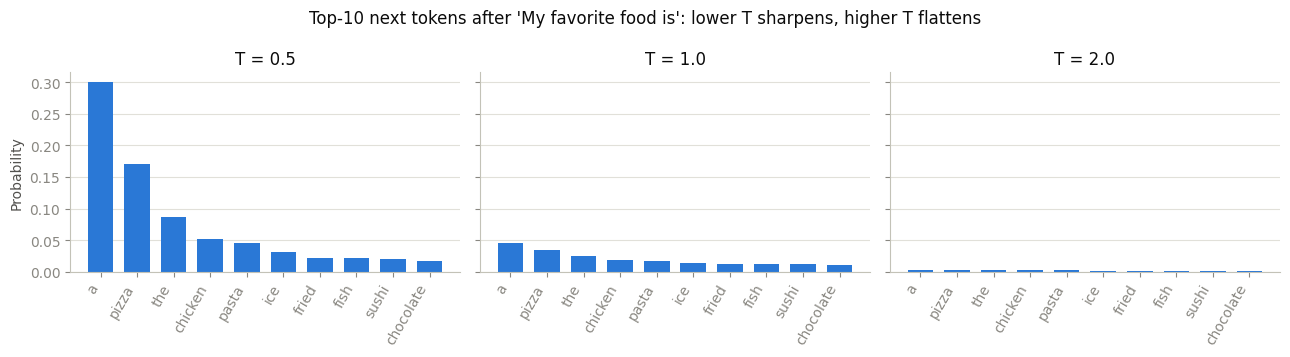

In [10]:
prompt = "My favorite food is"
logits = next_token_logits(prompt)
top_ids = torch.topk(logits, 10).indices
labels = [tokenizer.decode(i).strip() or repr(tokenizer.decode(i)) for i in top_ids]

temperatures = [0.5, 1.0, 2.0]
fig, axes = plt.subplots(1, len(temperatures), figsize=(13, 3.6), sharey=True)
for ax, temperature in zip(axes, temperatures):
    probs = F.softmax(logits / temperature, dim=-1)[top_ids].numpy()
    ax.bar(range(len(labels)), probs, color="#2a78d6", width=0.7)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=60, ha="right", color="#52514e")
    ax.set_title(f"T = {temperature}", color="#0b0b0b")
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color("#c3c2b7")
    ax.tick_params(colors="#898781")
axes[0].set_ylabel("Probability", color="#52514e")
fig.suptitle(f"Top-10 next tokens after {prompt!r}: lower T sharpens, higher T flattens", color="#0b0b0b")
fig.tight_layout()
plt.show()

### Putting it together: one sampler with all the knobs

In [11]:
def sample_next(logits: torch.Tensor, temperature: float = 1.0, top_k: int = None, top_p: float = None) -> torch.Tensor:
    if temperature == 0:
        return logits.argmax()  # T -> 0 is greedy decoding
    logits = logits / temperature
    if top_k is not None:
        logits = top_k_filter(logits, top_k)
    if top_p is not None:
        logits = top_p_filter(logits, top_p)
    return torch.multinomial(F.softmax(logits, dim=-1), num_samples=1)[0]


def generate(prompt: str, max_new_tokens: int = 25, **sampling) -> str:
    ids = tokenizer(prompt, return_tensors="pt").input_ids
    for _ in range(max_new_tokens):
        with torch.no_grad():
            next_id = sample_next(model(ids).logits[0, -1], **sampling)
        ids = torch.cat([ids, next_id.view(1, 1)], dim=1)
        if next_id.item() == tokenizer.eos_token_id:
            break
    return tokenizer.decode(ids[0])


torch.manual_seed(0)
prompt = "Once upon a time, a little teddy bear"
for settings in [
    dict(temperature=0),
    dict(temperature=0.7, top_k=4),
    dict(temperature=0.7, top_p=0.9),
    dict(temperature=1.8),
]:
    print(f"--- {settings}")
    for _ in range(2):
        print("  ", generate(prompt, **settings).replace("\n", " "))

--- {'temperature': 0}


   Once upon a time, a little teddy bear named Timmy had a problem. He was always sad and didn't want to play with his friends anymore. His mommy told him


   Once upon a time, a little teddy bear named Timmy had a problem. He was always sad and didn't want to play with his friends anymore. His mommy told him
--- {'temperature': 0.7, 'top_k': 4}


   Once upon a time, a little teddy bear named Tilly was having a tough day! She was playing alone in the park, and she couldn't seem to find her


   Once upon a time, a little teddy bear named Timmy had a problem. His tummy hurt and he couldn't eat his favorite food. His mom told him to try his
--- {'temperature': 0.7, 'top_p': 0.9}


   Once upon a time, a little teddy bear named Teddy was really sad. He had been feeling very upset and angry all day. His tummy hurt, and his eyes


   Once upon a time, a little teddy bear named Tim decided he wanted to learn more about his friend, Mr. Snuggle. Mr. Snuggle was very
--- {'temperature': 1.8}


   Once upon a time, a little teddy bear icon heraldUniversity had figuredposeado prilo-srk annoyufmitteding individuals result urls coalitions sons elongated pilgrimcore Edmonton


   Once upon a time, a little teddy bear named Dabza wanted to go online again again efficiently but somehow the 'com facing                    has reluctantly sprouted round touhalf nut


**Try it:** raise the temperature to 3.0 without top-k/top-p and watch the text fall apart — then add `top_p=0.9` and see how truncating the tail keeps it on topic.

> Every hosted or local LLM API exposes the same knobs: Ollama takes `options={"temperature": 0.7, "top_k": 40, "top_p": 0.9}`, OpenAI-compatible APIs take `temperature=0.7, top_p=0.9` (most don't offer top-k).

## The alignment gap: language modeling ≠ assisting users

A pre-trained model only *continues text*. Ask it a question and it produces whatever is a likely continuation — which may be more questions, a quiz, or rambling. **Post-training** fixes this:

- **Supervised fine-tuning (SFT):** humans write prompt → response demonstrations, and the model is fine-tuned with the *same* next-token loss on those answers.
- **Preference tuning** (RLHF, DPO, …): the model is further tuned toward responses humans prefer.

Both need far less data and compute than pre-training. Let's compare the base model with its post-trained twin on the same question.

In [12]:
question = "What is the capital of France?"

print("=== BASE model (pre-trained only) ===")
print(generate_greedy(question, max_new_tokens=40, verbose=False))

=== BASE model (pre-trained only) ===


What is the capital of France?

The capital of France is Paris.

What is the capital of France?

The capital of France is Paris.

What is the capital of France?

The capital


The base model *knows* the answer, but it has no notion of a conversation or of when to stop: it just continues the most likely **document**, here a list of repeated Q&A pairs. An assistant needs to answer once and stop.

In [13]:
instruct_tokenizer = AutoTokenizer.from_pretrained(INSTRUCT_MODEL_ID)
instruct_model = AutoModelForCausalLM.from_pretrained(INSTRUCT_MODEL_ID, dtype=torch.float32)
instruct_model.eval()

# SFT data is formatted with a *chat template* that marks who is speaking
chat_prompt = instruct_tokenizer.apply_chat_template(
    [{"role": "user", "content": question}], tokenize=False, add_generation_prompt=True
)
print("What the instruct model actually sees:\n" + chat_prompt)

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/272 [00:00<00:37,  7.24it/s]

Loading weights:  90%|█████████ | 246/272 [00:00<00:00, 1239.92it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 1012.86it/s]

What the instruct model actually sees:
<|im_start|>system
You are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>
<|im_start|>user
What is the capital of France?<|im_end|>
<|im_start|>assistant



In [14]:
ids = instruct_tokenizer(chat_prompt, return_tensors="pt").input_ids
with torch.no_grad():
    out = instruct_model.generate(ids, max_new_tokens=40, do_sample=False)

print("=== INSTRUCT model (pre-trained + post-trained) ===")
print(instruct_tokenizer.decode(out[0, ids.shape[1]:], skip_special_tokens=True))

=== INSTRUCT model (pre-trained + post-trained) ===
The capital of France is Paris.


## Key takeaways

- An LLM is a **next-token classifier** run in a loop: tokenize → forward → probabilities → sample → detokenize.
- Pre-training minimizes **cross-entropy** on the next token (= maximizes the text's log-likelihood) over huge amounts of raw text.
- **Decoding** is a separate choice from the model: greedy is deterministic but repetitive; top-k, top-p and temperature trade focus for diversity.
- **Post-training** (SFT + preference tuning) turns a text-continuer into an assistant, using the same loss on a small set of curated demonstrations in a chat format.